In [68]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, QuantileTransformer
from sklearn.metrics import (
   r2_score,
   mean_absolute_error,
   root_mean_squared_error
)
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn._config import set_config
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split


r2_score: 96.93
On average, my price guess is off by: $323.74
On average, my price guess is off by: $509.96


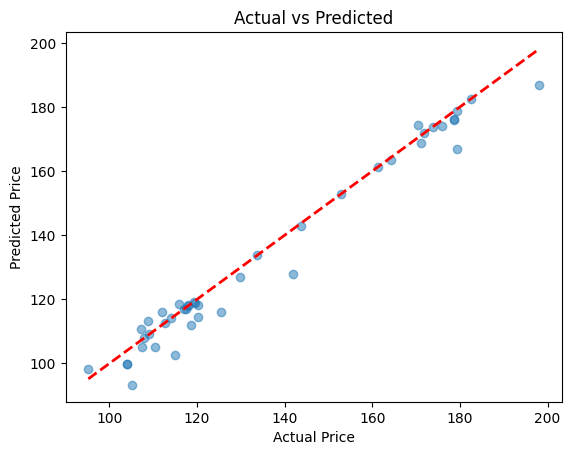

In [69]:
set_config(transform_output='pandas')

df = pd.read_csv("energy.csv")

X = df.drop(columns=['energy_consumption'])
y = df['energy_consumption']

# divide sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df = df.drop(columns=['timestamp'])

# preprocess data
categorical_features = X.select_dtypes(include=['str', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64', 'datetime64[ms, UTC]']).columns

# transforn data
preprocess = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),
        ("scaler", StandardScaler(), numerical_features)
    ]
)

# pipeline
pipe = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

# grid search
model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__n_jobs': [None],
    },
    scoring=['neg_mean_absolute_error', 'r2'],
    refit='neg_mean_absolute_error',
    cv=5,
    error_score='raise'
)

# fit or train model
model.fit(X_train, y_train)

# predict
model_prediction = model.predict(X_test)

# evaluate model
# accuracy score
r_2_score = r2_score(y_test, model_prediction)
print(f'r2_score: {r_2_score * 100:.2f}')

# recall score
mae = mean_absolute_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${mae * 100:.2f}')

rmse = root_mean_squared_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${rmse  * 100:.2f}')

plt.scatter(y_test, model_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

r2_score: 95.91
On average, my price guess is off by: $391.46
On average, my price guess is off by: $589.19


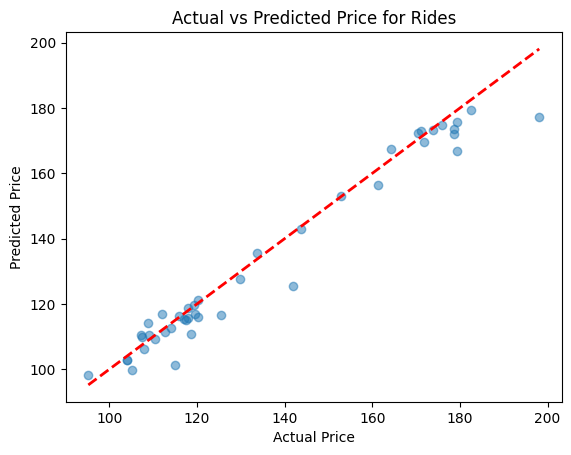

In [70]:
set_config(transform_output='pandas')

df = pd.read_csv("energy.csv")

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df = df.drop(columns=['timestamp'])

X = df.drop(columns=['energy_consumption'])
y = df['energy_consumption']

# divide sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# preprocess data
categorical_features = X.select_dtypes(include=['str', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

preprocess = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numerical_features),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)
# pipeline
pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

# grid search
model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__n_estimators': [15,],
        'model__max_depth': [10,]
    },
    scoring=['neg_mean_absolute_error', 'r2'],
    refit='neg_mean_absolute_error',
    cv=5,
    error_score='raise'
)
# fit or train model
model.fit(X_train, y_train)

# prediction
model_prediction = model.predict(X_test)

# evaluate model phase 
# accuracy score
r_2_score = r2_score(y_test, model_prediction)
print(f'r2_score: {r_2_score * 100:.2f}')

# recall score
mae = mean_absolute_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${mae * 100:.2f}')

rmse = root_mean_squared_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${rmse  * 100:.2f}')


plt.scatter(y_test, model_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price for Rides')
plt.show()

r2_score: 94.95
On average, my price guess is off by: $483.41
On average, my price guess is off by: $654.55


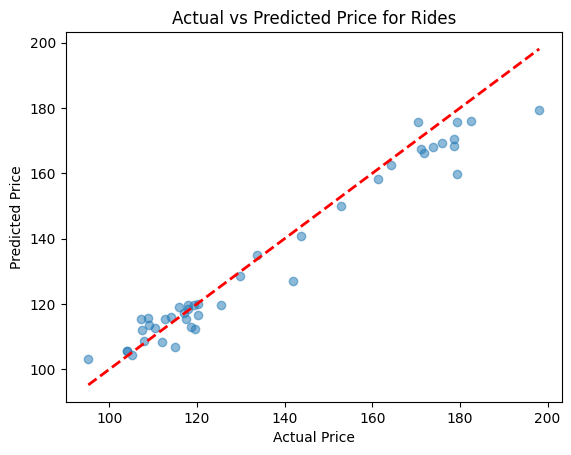

In [72]:
set_config(transform_output='pandas')

df = pd.read_csv("energy.csv")

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df = df.drop(columns=['timestamp'])

X = df.drop(columns=['energy_consumption',])
y = df['energy_consumption']

# divide sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# preprocess data
categorical_features = X.select_dtypes(include=['str', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

preprocess = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numerical_features),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)
# pipeline
pipe = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])


# grid search
model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__n_estimators': [20],
        'model__max_depth': [5]
    },
    scoring=['neg_mean_absolute_error', 'r2'],
    refit='neg_mean_absolute_error',
    cv=5,
    error_score='raise'
)
# fit or train model
model.fit(X_train, y_train)


# prediction
model_prediction = model.predict(X_test)

# evaluate model phase 
# accuracy score
r_2_score = r2_score(y_test, model_prediction)
print(f'r2_score: {r_2_score * 100:.2f}')

# recall score
mae = mean_absolute_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${mae * 100:.2f}')

rmse = root_mean_squared_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${rmse  * 100:.2f}')

plt.scatter(y_test, model_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price for Rides')
plt.show()